# Local Entropy Search (LES)

- Contributors: avrohr
- Last updated: Apr 15, 2026
- BoTorch version: v0.17.2


This notebook gives a short introduction to **Local Entropy Search (LES)** from:

David Stenger, Armin Lindicke, Alexander von Rohr, Sebastian Trimpe.
[*Local Entropy Search over Descent Sequences for Bayesian Optimization*](https://openreview.net/forum?id=cPxmLZmFa7). ICLR 2026.



## 1. LES in one page

LES is a **local** information-theoretic BO method. Instead of asking, "where is the global optimum?", it asks, "what can I learn about the descent sequence reachable from my current incumbent?". It thereby learns about a local optimum reachable from the current incumbent.

Let the current incumbent be $x_{\mathrm{inc}}$ and let $S = (x_0, x_1, \ldots, x_T)$ with $x_0 = x_{\mathrm{inc}}$ denote the descent sequence obtained by applying a local optimizer for a fixed number of steps to a sampled objective.

LES chooses the next query $x$ by maximizing the mutual information between the noisy observation at that point and the random descent sequence:

$$
\alpha_{\mathrm{LES}}(x)
= I\big(y(x); S \mid \mathcal{D}_n\big)
= H\big[y(x) \mid \mathcal{D}_n\big]
- \mathbb{E}_{S \mid \mathcal{D}_n}\left[H\big[y(x) \mid \mathcal{D}_n, S\big]\right].
$$

The practical approximation proposed in the paper and implemented in `botorch_community.acquisition.local_entropy_search.LocalEntropySearch` is:

1. draw posterior function samples using Matheron paths,
2. optimize each sampled path from the same incumbent,
3. discretize each sequence to a small number of support points,
4. condition the GP on those support points as virtual observations, and
5. compute predictive entropy minus average conditional entropy.

Current implementation constraints:

- single-output GP only,
- Sequential queries only: The paper also describes a batch LES variant in the appendix, but the current implementation supports only sequential queries.
- minimization or maximization controlled through `maximize=False/True`.




In [138]:
import botorch
import matplotlib.pyplot as plt
import torch
from botorch.fit import fit_gpytorch_mll
from botorch.models import SingleTaskGP
from botorch.optim import optimize_acqf
from botorch.models.transforms import Standardize
from botorch.test_functions.synthetic import Branin
from botorch.utils.sampling import draw_sobol_samples
from botorch.utils.transforms import unnormalize
from gpytorch.means import ConstantMean
from gpytorch.mlls import ExactMarginalLogLikelihood

from botorch_community.acquisition.local_entropy_search import LocalEntropySearch

torch.manual_seed(0)
torch.set_printoptions(precision=3, sci_mode=False)

plt.rcParams["figure.dpi"] = 120

device = torch.device("cpu")
dtype = torch.double
tkwargs = {"device": device, "dtype": dtype}
observation_noise_std = 0.25

print(f"BoTorch version: {botorch.__version__}")
print(f"Device: {device}")
print(f"Dtype: {dtype}")
print(f"Observation noise std: {observation_noise_std}")


BoTorch version: 0.1.dev2476+ga74cf943c
Device: cpu
Dtype: torch.float64
Observation noise std: 0.25


## 2. Problem setup and reusable helpers

We use **Branin** as a 2D minimization example. Inputs live in normalized coordinates $[0, 1]^2$, but the objective is evaluated in Branin's original domain via `unnormalize`.

We keep two evaluation functions throughout the notebook:

- a **latent** Branin objective for contour plots and proposal diagnostics, and
- a **noisy** observation model obtained by adding zero-mean Gaussian noise to the latent objective.

The helpers below keep the rest of the notebook focused on LES itself: fitting the GP, selecting the incumbent, building the acquisition function, extracting the paper-style candidate set from LES support points, and plotting the state of the optimization.

For the surrogate, we use a `SingleTaskGP` with standardized outputs and an explicit **trainable constant mean**.


In [139]:
true_function = Branin(negate=False).to(**tkwargs)
true_bounds = true_function.bounds.to(**tkwargs)
unit_bounds = torch.stack([
    torch.zeros(2, **tkwargs),
    torch.ones(2, **tkwargs),
])


def evaluate_true_objective(X_unit: torch.Tensor) -> torch.Tensor:
    X_orig = unnormalize(X_unit, bounds=true_bounds)
    return true_function(X_orig).unsqueeze(-1)


def evaluate_objective(
    X_unit: torch.Tensor,
    noise_std: float = observation_noise_std,
) -> torch.Tensor:
    y = evaluate_true_objective(X_unit)
    if noise_std <= 0:
        return y
    return y + noise_std * torch.randn_like(y)


def make_grid(n: int = 80) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
    x1 = torch.linspace(0.0, 1.0, n, **tkwargs)
    x2 = torch.linspace(0.0, 1.0, n, **tkwargs)
    X1, X2 = torch.meshgrid(x1, x2, indexing="xy")
    X = torch.stack([X1.reshape(-1), X2.reshape(-1)], dim=-1)
    return X1, X2, X


def format_point(X: torch.Tensor, digits: int = 3) -> list[float]:
    return [round(float(value), digits) for value in X.squeeze(0).tolist()]


def fit_model(train_X: torch.Tensor, train_Y: torch.Tensor) -> SingleTaskGP:
    model = SingleTaskGP(
        train_X=train_X,
        train_Y=train_Y,
        mean_module=ConstantMean(),
        outcome_transform=Standardize(m=1),
    )
    mll = ExactMarginalLogLikelihood(model.likelihood, model)
    fit_gpytorch_mll(mll)
    model.eval()
    model.likelihood.eval()
    return model


def get_best_observed(train_X: torch.Tensor, train_Y: torch.Tensor) -> torch.Tensor:
    best_idx = torch.argmin(train_Y.squeeze(-1))
    return train_X[best_idx].unsqueeze(0)


def get_posterior_mean_proposal(
    model: SingleTaskGP,
    *,
    grid_size: int = 120,
) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
    _, _, X_grid = make_grid(grid_size)
    with torch.no_grad():
        posterior_mean = model.posterior(X_grid.unsqueeze(-2)).mean.squeeze(-1).squeeze(-1)
    best_idx = torch.argmin(posterior_mean)
    return X_grid[best_idx].unsqueeze(0), X_grid, posterior_mean


def build_les(
    model: SingleTaskGP,
    x_incumbent: torch.Tensor,
    *,
    num_path_samples: int = 48,
    num_descent_steps: int = 96,
    learning_rate: float = 2e-3,
    sequence_discretization_size: int = 8,
    sequence_subsample_size: int | None = None,
    conditional_model_chunk_size: int | None = 8,
    convergence_tol: float | None = 1e-6,
) -> LocalEntropySearch:
    return LocalEntropySearch(
        model=model,
        x_incumbent=x_incumbent,
        num_path_samples=num_path_samples,
        num_descent_steps=num_descent_steps,
        learning_rate=learning_rate,
        maximize=False,
        bounds=unit_bounds,
        sequence_discretization_size=sequence_discretization_size,
        sequence_subsample_size=sequence_subsample_size,
        conditional_model_chunk_size=conditional_model_chunk_size,
        convergence_tol=convergence_tol,
    )


def predictive_entropy(
    model: SingleTaskGP,
    X: torch.Tensor,
    min_variance: float = 1e-6,
) -> torch.Tensor:
    posterior = model.posterior(X=X, observation_noise=True)
    variance = posterior.variance.squeeze(-1).squeeze(-1).clamp_min(min_variance)
    return 0.5 * torch.log(2.0 * torch.pi * torch.e * variance)


def get_sequence_candidate_set(les: LocalEntropySearch) -> torch.Tensor:
    candidate_X = torch.cat(les.sequence_X_per_path, dim=0)
    return torch.unique(candidate_X, dim=0)


def select_les_query(
    les: LocalEntropySearch,
    train_X: torch.Tensor,
) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
    candidate_X = get_sequence_candidate_set(les)
    candidate_values = les(candidate_X.unsqueeze(-2))

    min_dist = torch.cdist(candidate_X, train_X).min(dim=1).values
    unseen = min_dist > 1e-9
    if torch.any(unseen):
        masked_values = candidate_values.clone()
        masked_values[~unseen] = -torch.inf
        best_idx = torch.argmax(masked_values)
    else:
        best_idx = torch.argmax(candidate_values)

    return candidate_X[best_idx].unsqueeze(0), candidate_X, candidate_values


def plot_les_state(
    model: SingleTaskGP,
    les: LocalEntropySearch,
    train_X: torch.Tensor,
    incumbent: torch.Tensor,
    *,
    proposal_x: torch.Tensor | None = None,
    query_x: torch.Tensor | None = None,
    title_prefix: str = "LES state",
    grid_size: int = 80,
    num_paths_to_plot: int = 12,
) -> None:
    X1, X2, X_grid = make_grid(grid_size)
    candidate_X = get_sequence_candidate_set(les)
    if proposal_x is None:
        proposal_x = incumbent

    with torch.no_grad():
        y_true = evaluate_true_objective(X_grid).reshape_as(X1)
        gp_mean = model.posterior(X_grid.unsqueeze(-2)).mean.squeeze(-1).squeeze(-1)
        gp_mean = gp_mean.reshape_as(X1)
        entropy = predictive_entropy(model, X_grid.unsqueeze(-2)).reshape_as(X1)
        les_values = les(X_grid.unsqueeze(-2)).reshape_as(X1)

    fig, axes = plt.subplots(1, 4, figsize=(22, 5), constrained_layout=True)
    fig.suptitle(title_prefix, y=1.02)

    cf0 = axes[0].contourf(X1.cpu(), X2.cpu(), y_true.cpu(), levels=40, cmap="viridis")
    axes[0].scatter(train_X[:, 0].cpu(), train_X[:, 1].cpu(), color="black", s=24, label="Observed points")
    axes[0].scatter(proposal_x[:, 0].cpu(), proposal_x[:, 1].cpu(), marker="*", s=140, color="tab:red", label="Proposal / incumbent")
    if query_x is not None:
        axes[0].scatter(query_x[:, 0].cpu(), query_x[:, 1].cpu(), marker="X", s=100, color="tab:blue", label="LES query")
    axes[0].set_title("True objective")
    axes[0].set_xlabel("x1 (normalized)")
    axes[0].set_ylabel("x2 (normalized)")
    axes[0].set_aspect("equal")
    axes[0].legend(loc="upper right")
    fig.colorbar(cf0, ax=axes[0], shrink=0.82)

    cf1 = axes[1].contourf(X1.cpu(), X2.cpu(), gp_mean.cpu(), levels=40, cmap="cividis")
    axes[1].scatter(train_X[:, 0].cpu(), train_X[:, 1].cpu(), color="black", s=24)
    axes[1].scatter(proposal_x[:, 0].cpu(), proposal_x[:, 1].cpu(), marker="*", s=140, color="tab:red")
    for path_idx, sequence_X in enumerate(les.sequence_X_per_path[:num_paths_to_plot]):
        sequence_X = sequence_X.detach().cpu()
        axes[1].plot(
            sequence_X[:, 0],
            sequence_X[:, 1],
            color="tab:orange",
            alpha=0.8,
            linewidth=1.0,
            marker="o",
            markersize=2.5,
            label="Discretized LES sequences" if path_idx == 0 else None,
        )
    axes[1].set_title("GP mean + LES support paths")
    axes[1].set_xlabel("x1 (normalized)")
    axes[1].set_ylabel("x2 (normalized)")
    axes[1].set_aspect("equal")
    if num_paths_to_plot > 0:
        axes[1].legend(loc="upper right")
    fig.colorbar(cf1, ax=axes[1], shrink=0.82)

    cf2 = axes[2].contourf(X1.cpu(), X2.cpu(), entropy.cpu(), levels=40, cmap="plasma")
    axes[2].scatter(train_X[:, 0].cpu(), train_X[:, 1].cpu(), color="white", s=20, edgecolors="black")
    axes[2].scatter(proposal_x[:, 0].cpu(), proposal_x[:, 1].cpu(), marker="*", s=140, color="tab:red")
    axes[2].set_title("Predictive entropy")
    axes[2].set_xlabel("x1 (normalized)")
    axes[2].set_ylabel("x2 (normalized)")
    axes[2].set_aspect("equal")
    fig.colorbar(cf2, ax=axes[2], shrink=0.82)

    cf3 = axes[3].contourf(X1.cpu(), X2.cpu(), les_values.cpu(), levels=40, cmap="magma")
    axes[3].scatter(candidate_X[:, 0].cpu(), candidate_X[:, 1].cpu(), s=10, color="white", alpha=0.55, label="Candidate set")
    axes[3].scatter(train_X[:, 0].cpu(), train_X[:, 1].cpu(), color="black", s=22, label="Observed points")
    axes[3].scatter(proposal_x[:, 0].cpu(), proposal_x[:, 1].cpu(), marker="*", s=140, color="tab:red", label="Proposal / incumbent")
    if query_x is not None:
        axes[3].scatter(query_x[:, 0].cpu(), query_x[:, 1].cpu(), marker="X", s=100, color="tab:blue", label="LES query")
    axes[3].set_title("LES acquisition")
    axes[3].set_xlabel("x1 (normalized)")
    axes[3].set_ylabel("x2 (normalized)")
    axes[3].set_aspect("equal")
    axes[3].legend(loc="upper right")
    fig.colorbar(cf3, ax=axes[3], shrink=0.82)

    plt.show()


## 3. Instantiate LES in BoTorch

We now fit a small GP, compute a **proposal** as the minimizer of the GP posterior mean on a dense 2D grid, use that proposal as the LES incumbent, build LES, and select the next query from the **union of sequence support points**.


In [140]:
n_init = 8
train_X = draw_sobol_samples(bounds=unit_bounds, n=n_init, q=1).squeeze(1).to(**tkwargs)
train_Y = evaluate_objective(train_X)

model = fit_model(train_X, train_Y)
best_observed = get_best_observed(train_X, train_Y)
proposal_x, _, _ = get_posterior_mean_proposal(model, grid_size=120)
incumbent = proposal_x.clone()
les = build_les(
    model,
    incumbent,
    num_path_samples=128,
    num_descent_steps=256,
    sequence_discretization_size=8,
    conditional_model_chunk_size=8,
)

next_x, candidate_X, candidate_values = select_les_query(les, train_X)
proposal_y = evaluate_true_objective(proposal_x)

print(f"Best observed point: {format_point(best_observed)}")
print(f"Proposal / incumbent: {format_point(proposal_x)}")
print(f"Latent objective at proposal: {float(proposal_y.item()):.3f}")
print(f"Incumbent: {format_point(incumbent)}")
print(f"Number of LES paths: {len(les.sequence_X_per_path)}")
print(f"Support points per path: {les.sequence_X_per_path[0].shape[0]}")
print(f"Candidate set size: {candidate_X.shape[0]}")
print(f"Next LES query: {format_point(next_x)}")
print(f"Maximum LES value on candidate set: {candidate_values.max().item():.3f}")


Best observed point: [0.579, 0.037]
Proposal / incumbent: [0.63, 0.168]
Latent objective at proposal: 8.640
Incumbent: [0.63, 0.168]
Number of LES paths: 128
Support points per path: 8
Candidate set size: 1024
Next LES query: [0.65, 0.203]
Maximum LES value on candidate set: 1.747


## 4. 2D visual intuition

The four panels below are meant to be read together:

- the true objective tells us where the local minima actually are,
- the GP mean and discretized LES paths show what the model currently believes is reachable from the proposal/incumbent,
- the predictive entropy shows where the surrogate is uncertain, and
- the LES acquisition shows where information about the descent sequence is most valuable.

The red star marks the posterior-mean proposal used as the LES incumbent. The blue `X` marks the LES query selected for entropy reduction.

For interpretability, the acquisition is plotted on a dense grid, but the LES query itself still comes from the support-point candidate set.


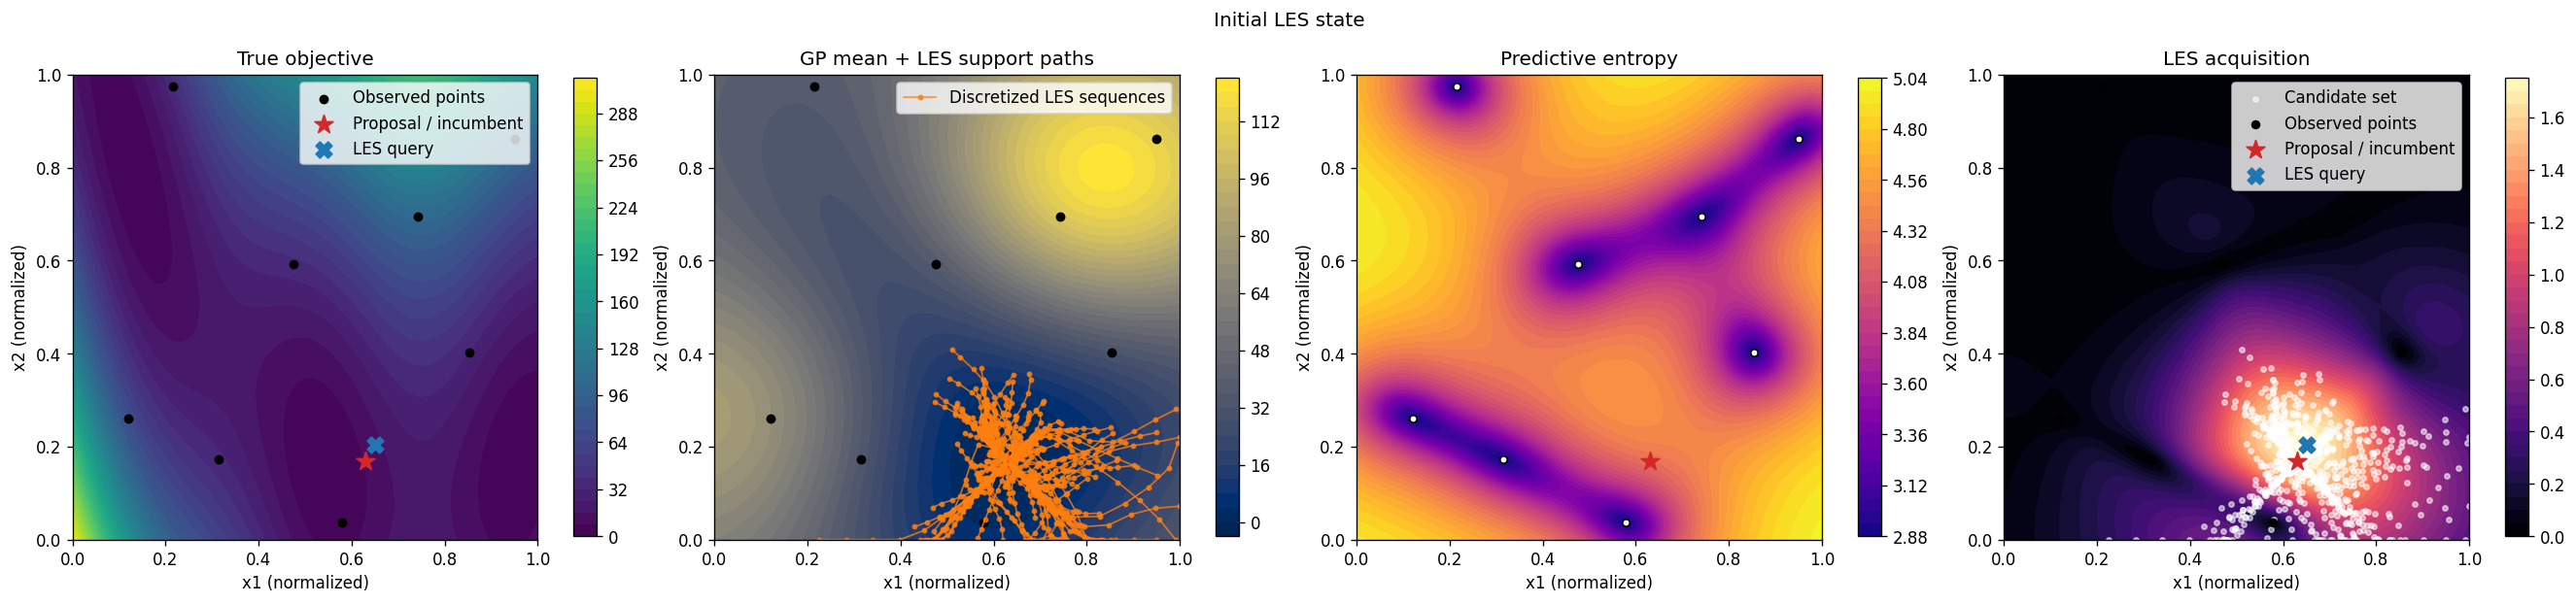

In [141]:
plot_les_state(
    model,
    les,
    train_X,
    incumbent,
    proposal_x=proposal_x,
    query_x=next_x,
    title_prefix="Initial LES state",
    grid_size=80,
    num_paths_to_plot=128,
)


## 5. LES over multiple BO steps

Finally, we run a short LES loop. Each iteration does the following:

1. fit a GP to the current data,
2. compute a proposal as the minimizer of the GP posterior mean,
3. use that proposal as the LES incumbent,
4. build LES from that incumbent,
5. choose the next query from the union of LES support points, and
6. evaluate the objective and append the new observation.

Because LES reduces uncertainty about the descent sequence, the entropy-reducing query is not required to coincide with the model's predicted optimum. For that reason, we keep the loop diagnostics for both LES queries and GP proposals.

The GP is fit to **noisy observations** of Branin. In the final summary figure, we only show the **latent objective at the proposal** together with the **Branin global minimum**. This keeps the summary plot focused on predicted optima rather than entropy-reducing samples.


Iteration 0: best_observed=[0.579, 0.037], proposal=[0.63, 0.168], latent_proposal_y=8.640, incumbent=[0.63, 0.168], query=[0.652, 0.203], query_y=14.189, latent_query_y=13.542, candidate_set=1021
Iteration 1: best_observed=[0.579, 0.037], proposal=[0.538, 0.008], latent_proposal_y=5.298, incumbent=[0.538, 0.008], query=[0.429, 0.0], query_y=27.058, latent_query_y=27.156, candidate_set=1024
Iteration 2: best_observed=[0.579, 0.037], proposal=[0.639, 0.034], latent_proposal_y=9.571, incumbent=[0.639, 0.034], query=[0.719, 0.0], query_y=19.677, latent_query_y=19.701, candidate_set=1023
Iteration 3: best_observed=[0.579, 0.037], proposal=[0.571, 0.092], latent_proposal_y=1.604, incumbent=[0.571, 0.092], query=[0.506, 0.137], query_y=2.398, latent_query_y=2.351, candidate_set=1024
Iteration 4: best_observed=[0.506, 0.137], proposal=[0.597, 0.101], latent_proposal_y=3.412, incumbent=[0.597, 0.101], query=[0.707, 0.106], query_y=17.766, latent_query_y=17.691, candidate_set=1024
Iteration 5: 

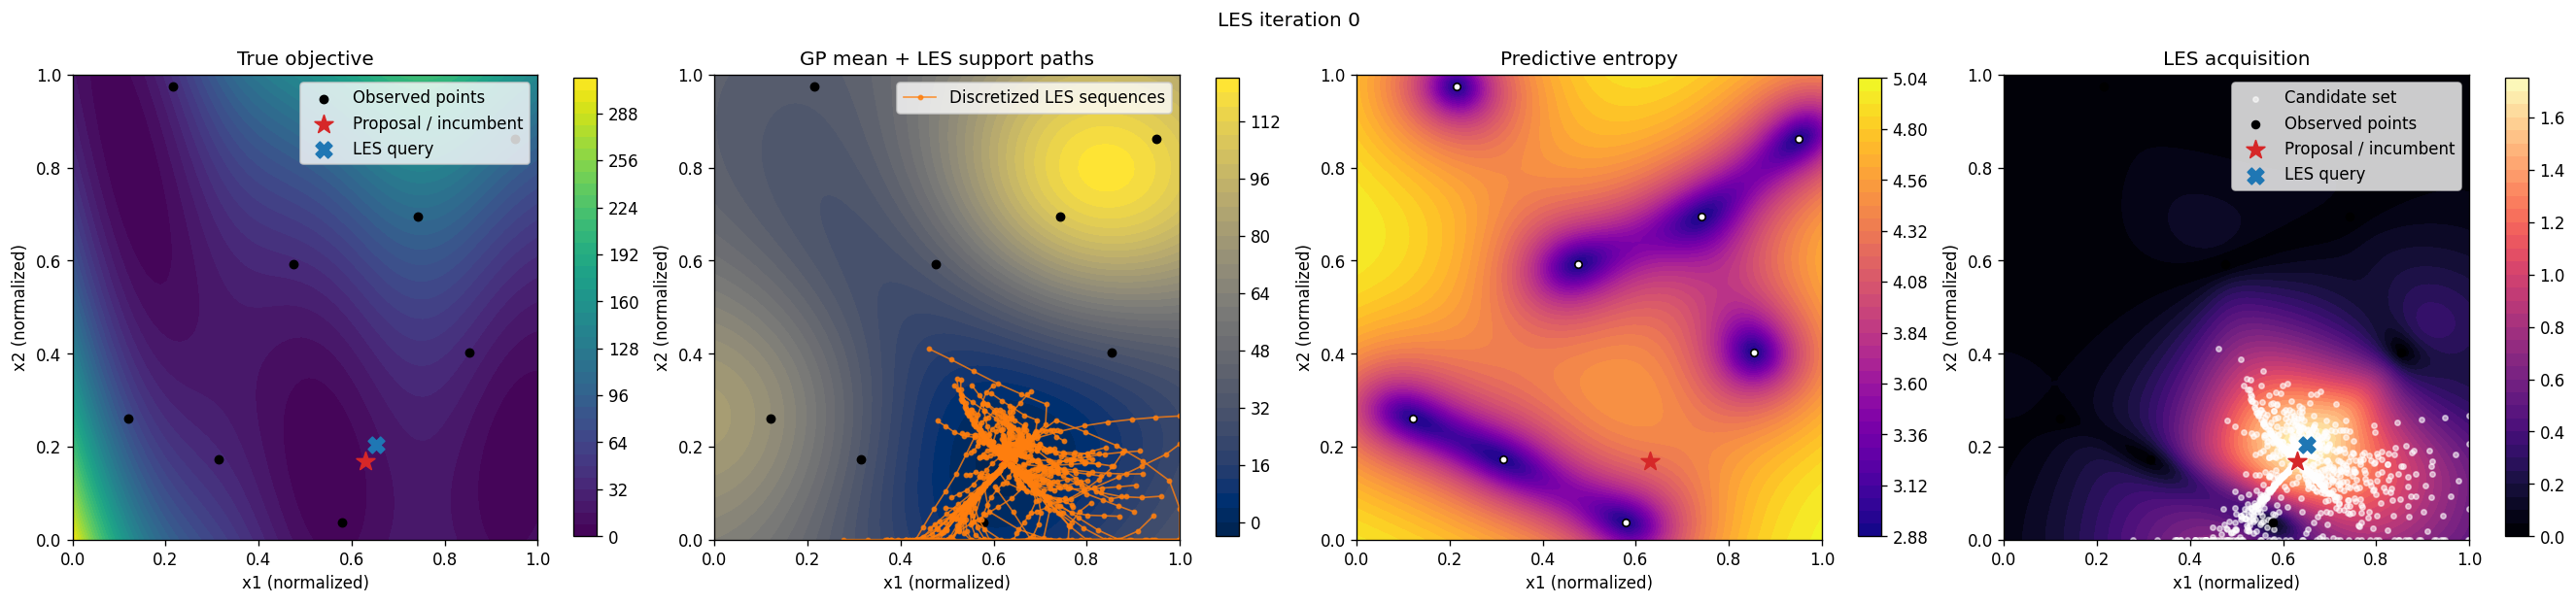

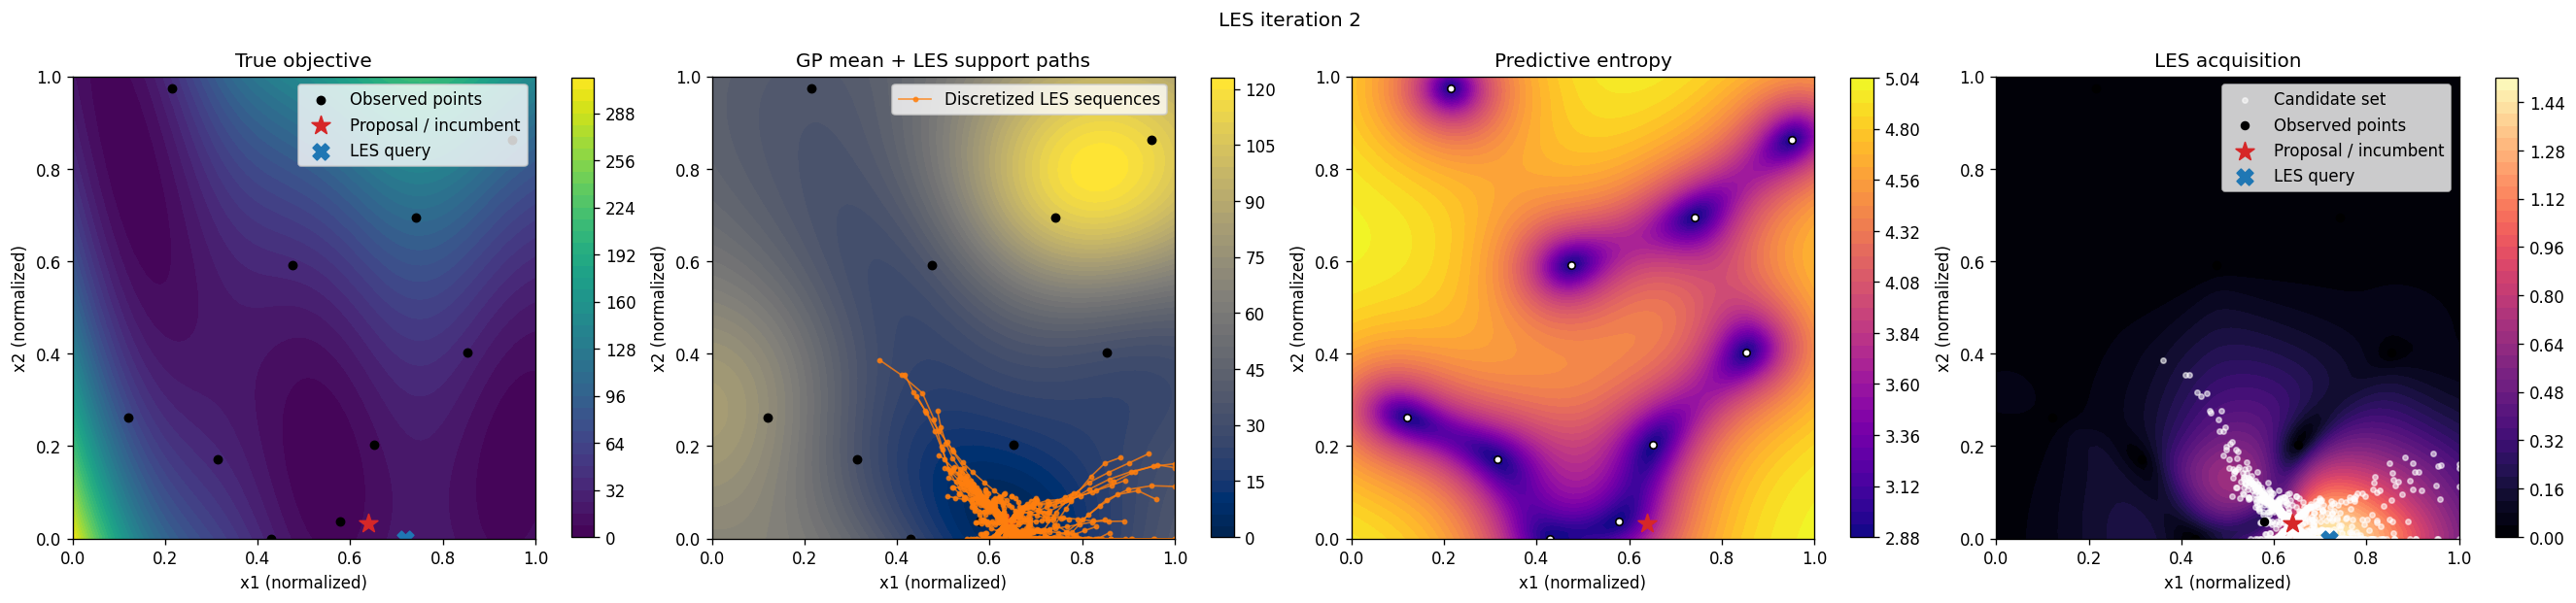

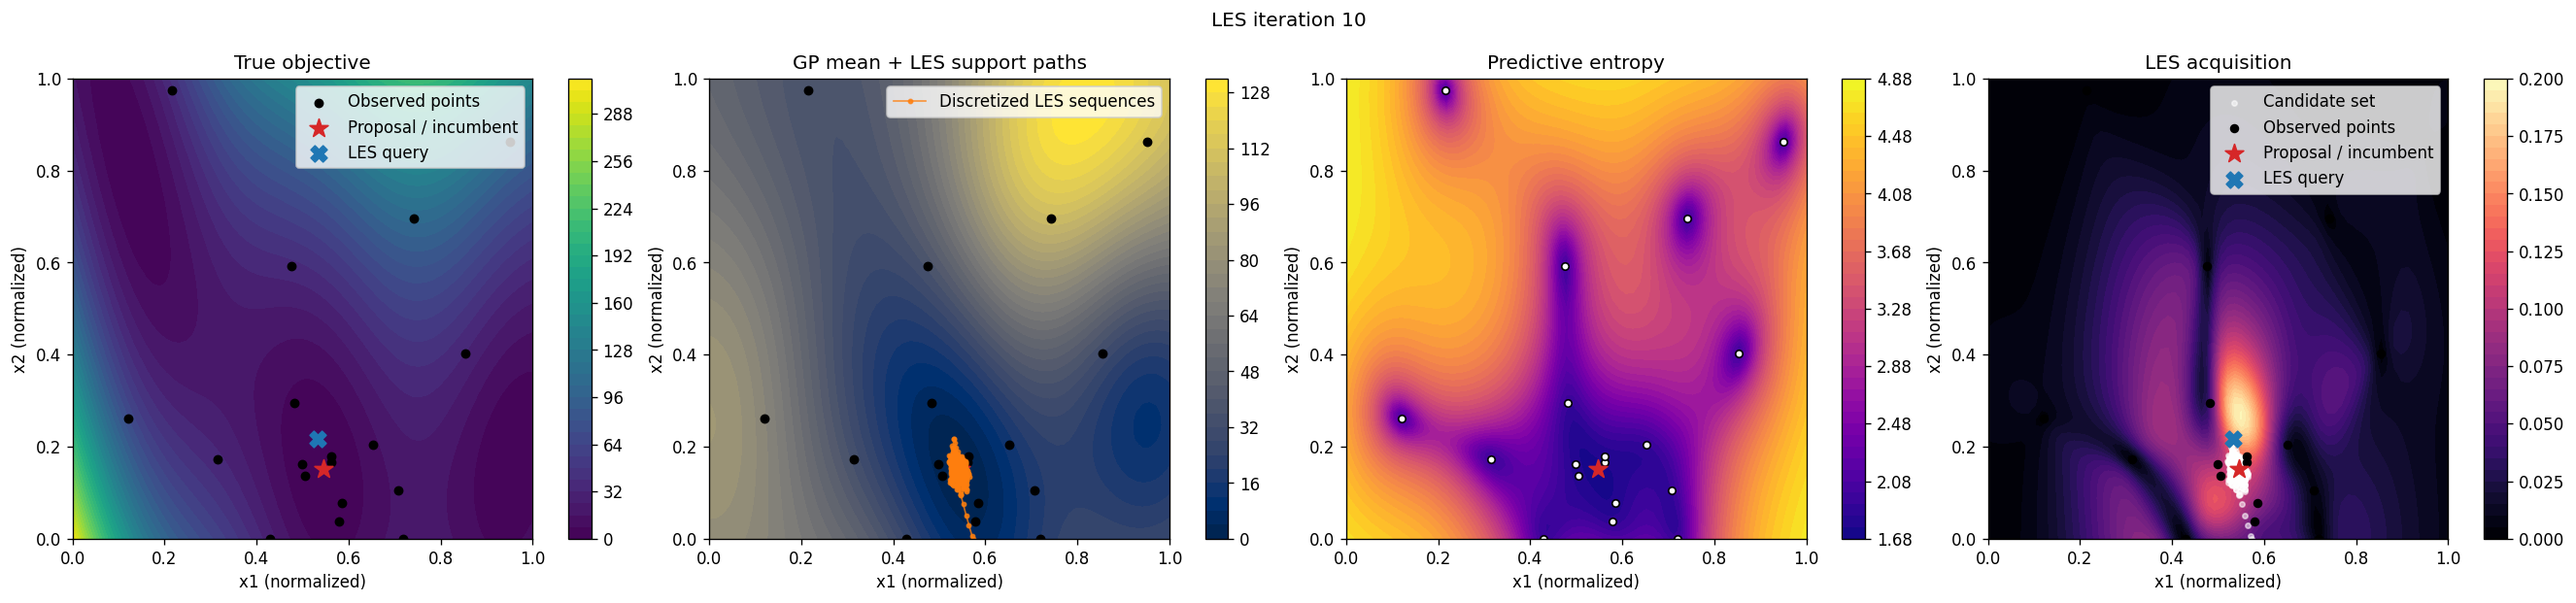

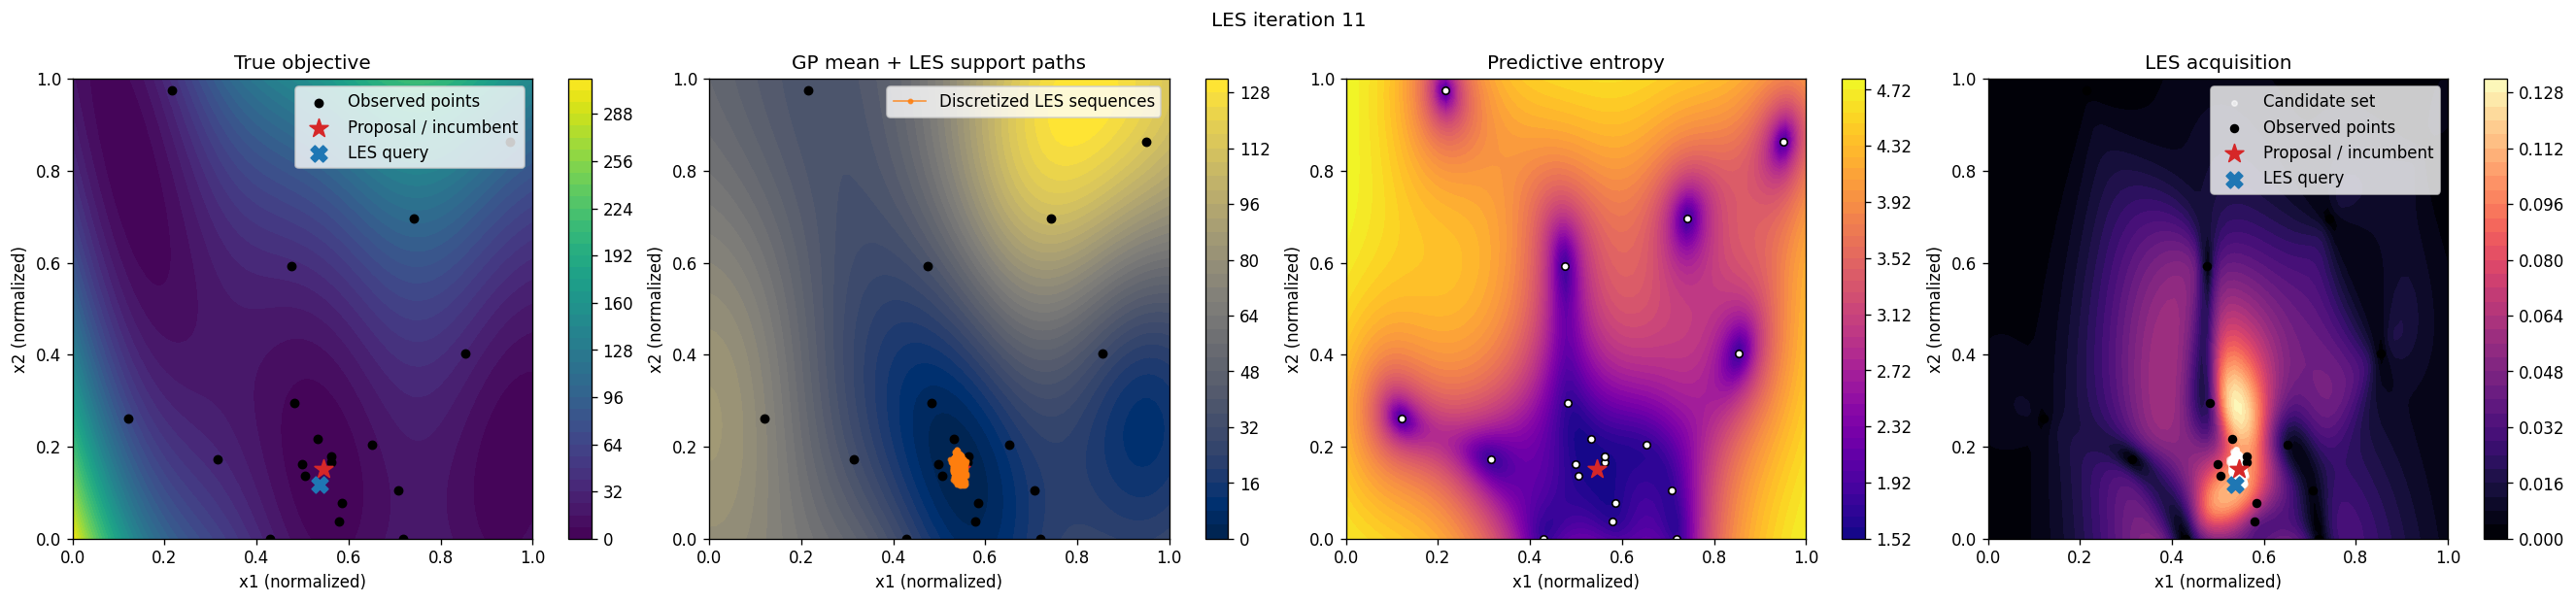

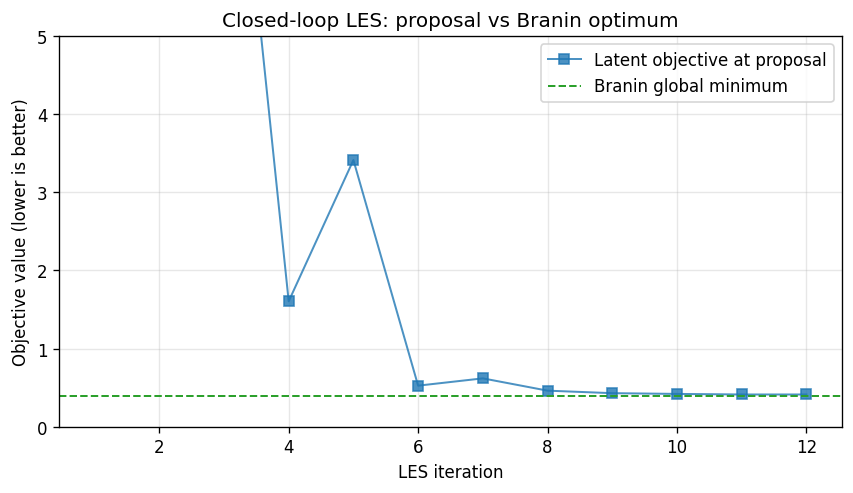

In [142]:
n_bo_steps = 12
bo_train_X = train_X.clone()
bo_train_Y = train_Y.clone()

best_latent_history = [float(evaluate_true_objective(bo_train_X).min().item())]
query_y_history: list[float] = []
query_latent_y_history: list[float] = []
proposal_y_history: list[float] = []
snapshots = []
plot_iterations = {0, 2, n_bo_steps - 2, n_bo_steps - 1}

for iteration in range(n_bo_steps):
    model_iter = fit_model(bo_train_X, bo_train_Y)
    best_observed_iter = get_best_observed(bo_train_X, bo_train_Y)
    proposal_iter, _, _ = get_posterior_mean_proposal(model_iter, grid_size=120)
    incumbent_iter = proposal_iter.clone()
    les_iter = build_les(
        model_iter,
        incumbent_iter,
        num_path_samples=128,
        num_descent_steps=256,
        sequence_discretization_size=8,
        conditional_model_chunk_size=8,
    )

    query_x, candidate_X_iter, candidate_values_iter = select_les_query(les_iter, bo_train_X)
    query_y = evaluate_objective(query_x)
    query_latent_y = evaluate_true_objective(query_x)
    proposal_y = evaluate_true_objective(proposal_iter)

    if iteration in plot_iterations:
        snapshots.append(
            (
                iteration,
                model_iter,
                les_iter,
                bo_train_X.clone(),
                incumbent_iter.clone(),
                proposal_iter.clone(),
                query_x.clone(),
            )
        )

    query_y_history.append(float(query_y.item()))
    query_latent_y_history.append(float(query_latent_y.item()))
    proposal_y_history.append(float(proposal_y.item()))

    bo_train_X = torch.cat([bo_train_X, query_x], dim=0)
    bo_train_Y = torch.cat([bo_train_Y, query_y], dim=0)

    best_latent_history.append(float(evaluate_true_objective(bo_train_X).min().item()))

    print(
        f"Iteration {iteration}: best_observed={format_point(best_observed_iter)}, "
        f"proposal={format_point(proposal_iter)}, "
        f"latent_proposal_y={float(proposal_y.item()):.3f}, "
        f"incumbent={format_point(incumbent_iter)}, "
        f"query={format_point(query_x)}, "
        f"query_y={float(query_y.item()):.3f}, "
        f"latent_query_y={float(query_latent_y.item()):.3f}, "
        f"candidate_set={candidate_X_iter.shape[0]}"
    )

for iteration, snapshot_model, snapshot_les, snapshot_train_X, snapshot_incumbent, snapshot_proposal, snapshot_query in snapshots:
    plot_les_state(
        snapshot_model,
        snapshot_les,
        snapshot_train_X,
        snapshot_incumbent,
        proposal_x=snapshot_proposal,
        query_x=snapshot_query,
        title_prefix=f"LES iteration {iteration}",
        grid_size=70,
        num_paths_to_plot=128,
    )

fig, ax = plt.subplots(figsize=(7, 4), constrained_layout=True)
ax.plot(range(1, n_bo_steps + 1), proposal_y_history, marker="s", linewidth=1.2, alpha=0.8, label="Latent objective at proposal")
ax.axhline(float(true_function.optimal_value), color="tab:green", linestyle="--", linewidth=1.2, label="Branin global minimum")
ax.set_xlabel("LES iteration")
ax.set_ylabel("Objective value (lower is better)")
ax.set_title("Closed-loop LES: proposal vs Branin optimum")
ax.set_ylim(bottom=0.0, top=5.0)
ax.grid(alpha=0.3)
ax.legend(loc="upper right")
plt.show()


## 6. Adapting LES to your problem

A minimal LES workflow for a new problem is:

1. normalize inputs to $[0, 1]^d$,
2. fit a single-output GP to your current data,
3. choose a proposal/incumbent rule, for example the minimizer of the posterior mean in the noisy setting,
4. build `LocalEntropySearch(model, x_incumbent=proposal, ...)`,
5. optimize the acquisition or evaluate it on a finite candidate set, and
6. evaluate the selected point on the real objective and refit.

In this notebook we used the **union of LES support points** as a finite candidate set because it aligns naturally with the practical sequence-based approximation. But LES is also a standard BoTorch acquisition function, so you can optimize it directly with `optimize_acqf`.


In [143]:
support_query_x, support_candidate_X, support_candidate_values = select_les_query(les_iter, bo_train_X)

def optimize_les_query_continuous(
    les: LocalEntropySearch,
    *,
    num_restarts: int = 10,
    raw_samples: int = 128,
) -> tuple[torch.Tensor, torch.Tensor]:
    candidate, acq_value = optimize_acqf(
        acq_function=les,
        bounds=unit_bounds,
        q=1,
        num_restarts=num_restarts,
        raw_samples=raw_samples,
    )
    return candidate, acq_value


continuous_query_x, continuous_acq_value = optimize_les_query_continuous(
    les_iter,
    num_restarts=8,
    raw_samples=64,
)

print(f"Support-point LES query: {format_point(support_query_x)}")
print(f"Support-point LES value: {float(support_candidate_values.max().item()):.3f}")
print(f"Continuous optimize_acqf LES query: {format_point(continuous_query_x)}")
print(f"Continuous optimize_acqf LES value: {float(continuous_acq_value.item()):.3f}")


Support-point LES query: [0.539, 0.119]
Support-point LES value: 0.111
Continuous optimize_acqf LES query: [0.543, 0.285]
Continuous optimize_acqf LES value: 0.130


## 7. Practical checklist and caveats

- The current implementation supports **single-output** models only.
- Sequential queries only: The paper also describes a batch LES variant in the appendix, but the current implementation supports only sequential queries.
- Larger `num_path_samples` and `num_descent_steps` usually improve the approximation, but they increase runtime and memory use.
- `sequence_discretization_size` and `sequence_subsample_size` control how much of each path is retained when constructing the sequence variable.
- `conditional_model_chunk_size` is useful when conditioning on all path supports at once becomes too memory intensive.
- The **proposal/incumbent** and the **LES query** serve different roles: the proposal summarizes where the model thinks the local optimum is, while the LES query is chosen for information gain about the local descent sequence. For noisy problems you might want to choose the argmin of the GP posterior mean as incumbent.
- If you want a paper-aligned practical approximation, querying from the sequence support-point candidate set is a sensible choice. If you want a simpler BoTorch-native workflow, direct `optimize_acqf` optimization also works.

With those caveats in mind, the notebook now contains both an interpretable 2D LES example and a reusable template for running LES in a standard BoTorch loop.
